# Exploratory Data Analysis
### VALORANT Player Retention & Meta Analytics Platform — Phase 4

Quick visual sanity-checks on the dataset before/alongside the ML modeling work in
`churn_model.py`, `shap_analysis.py`, and `player_segmentation.py`. This notebook is
exploratory, not the analysis pipeline itself — the real pipeline lives in `sql/` and `ml/`.


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
conn = sqlite3.connect("../data/processed/valorant_analytics.db")


## 1. Rank distribution across the player base

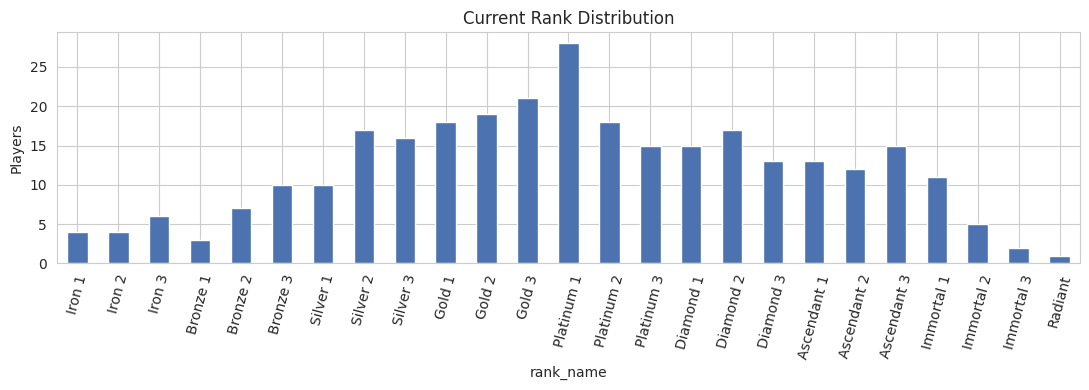

In [2]:
rank_dist = pd.read_sql("SELECT * FROM v_player_current_rank", conn)
order = rank_dist.sort_values("rank_tier_order")["rank_name"].unique()
counts = rank_dist["rank_name"].value_counts().reindex(order)

plt.figure(figsize=(11,4))
counts.plot(kind="bar", color="#4C72B0")
plt.title("Current Rank Distribution")
plt.ylabel("Players")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 2. Win rate and ACS by rank tier (sanity check — should trend upward with skill)

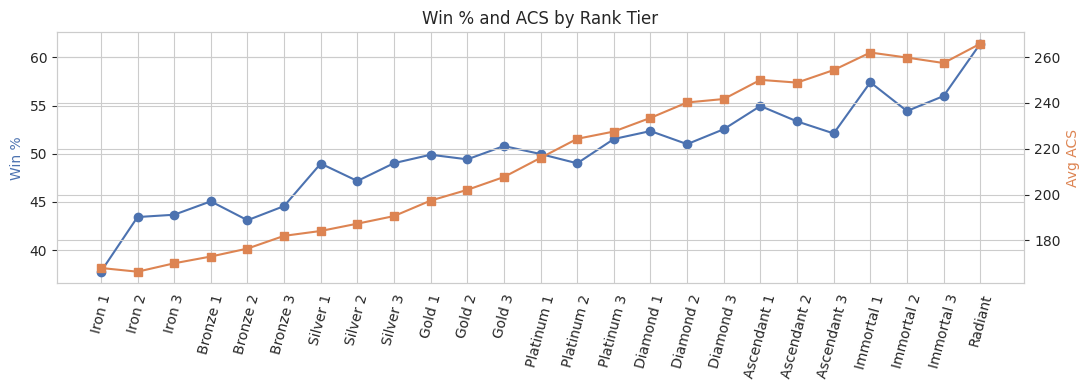

In [3]:
q = '''
SELECT r.rank_name, r.rank_tier_order,
       100.0*SUM(CASE WHEN m.match_result='Win' THEN 1 ELSE 0 END)/COUNT(*) AS win_pct,
       AVG(m.acs) AS avg_acs
FROM matches m JOIN ranks r ON r.rank_id = m.rank_id
GROUP BY r.rank_name, r.rank_tier_order ORDER BY r.rank_tier_order
'''
rank_perf = pd.read_sql(q, conn)

fig, ax1 = plt.subplots(figsize=(11,4))
ax1.plot(rank_perf.rank_name, rank_perf.win_pct, marker='o', color='#4C72B0', label='Win %')
ax1.set_ylabel('Win %', color='#4C72B0')
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(rank_perf.rank_name, rank_perf.avg_acs, marker='s', color='#DD8452', label='Avg ACS')
ax2.set_ylabel('Avg ACS', color='#DD8452')
plt.title("Win % and ACS by Rank Tier")
plt.tight_layout()
plt.show()


## 3. Agent pick rate — top 10

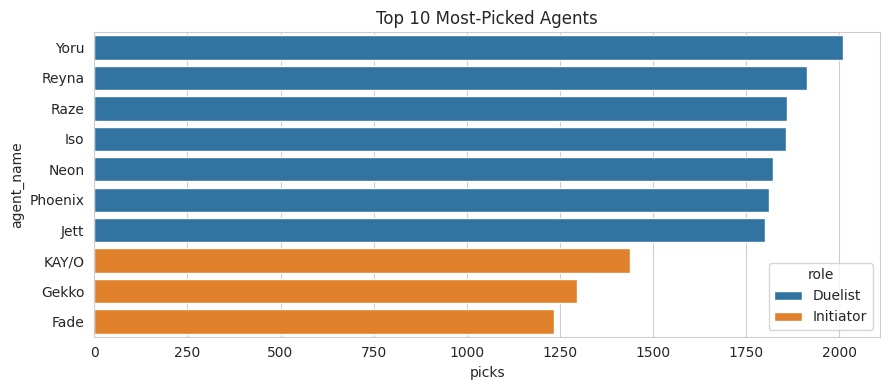

In [4]:
q = '''
SELECT a.agent_name, a.role, COUNT(*) as picks
FROM matches m JOIN agents a ON a.agent_id = m.agent_id
GROUP BY a.agent_name ORDER BY picks DESC LIMIT 10
'''
agent_picks = pd.read_sql(q, conn)

plt.figure(figsize=(9,4))
sns.barplot(data=agent_picks, y="agent_name", x="picks", hue="role", dodge=False)
plt.title("Top 10 Most-Picked Agents")
plt.tight_layout()
plt.show()


## 4. Session duration distribution

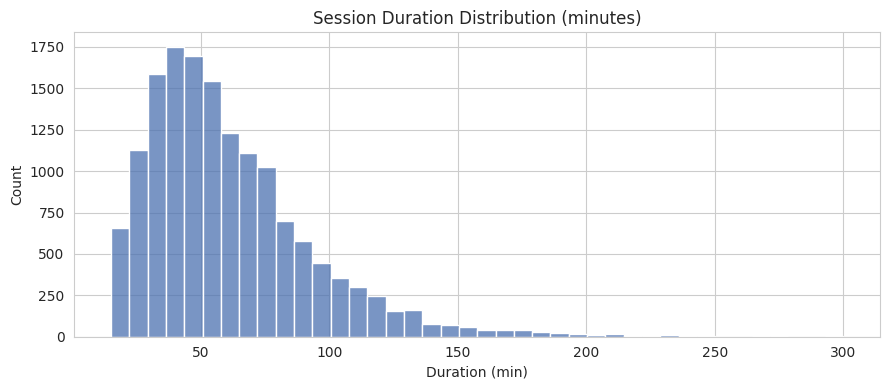

In [5]:
sessions = pd.read_sql("SELECT session_duration_min FROM player_sessions", conn)

plt.figure(figsize=(9,4))
sns.histplot(sessions.session_duration_min, bins=40, color="#4C72B0")
plt.title("Session Duration Distribution (minutes)")
plt.xlabel("Duration (min)")
plt.tight_layout()
plt.show()


## 5. Churn rate by player segment (output from `player_segmentation.py`)

In [6]:
segments = pd.read_csv("../data/processed/player_segments.csv")
seg_summary = segments.groupby("segment_name").agg(
    players=("player_id","count"),
    churn_rate=("churned","mean"),
    avg_sessions_per_week=("sessions_per_week","mean"),
).sort_values("churn_rate", ascending=False)
seg_summary["churn_rate"] = (seg_summary["churn_rate"]*100).round(1)
seg_summary


,players,churn_rate,avg_sessions_per_week
segment_name,,,
Casual Regular,51,25.5,2.297255
At-Risk / Low Engagement,60,16.7,1.771833
Social / Party Player,108,8.3,3.228889
Hardcore Core,81,0.0,4.791975


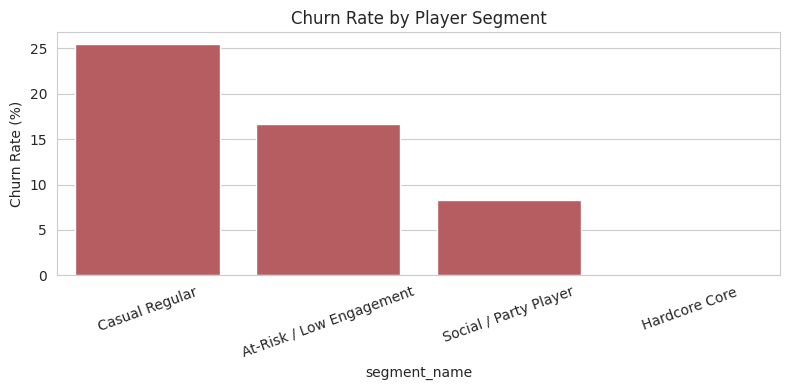

In [7]:
plt.figure(figsize=(8,4))
sns.barplot(data=seg_summary.reset_index(), x="segment_name", y="churn_rate", color="#C44E52")
plt.title("Churn Rate by Player Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Notes
- Win %/ACS trending upward with rank tier (section 2) confirms the simulated skill model is internally consistent.
- Session duration distribution (section 4) is right-skewed, as expected for a lognormal generation process.
- Segment churn rates (section 5) show frequency alone doesn't fully explain churn — see `docs/03_BUSINESS_QUESTIONS.md` and the Phase 4 write-up for the full discussion.
